# Retail Inventory and Sales Analysis

## Project Overview

This project analyzes retail sales data from a simulated clothing store.

The store has three main zones:

- Men
- Women
- Kids

Each zone contains different types of products such as clothing, accessories, and perfume.

The goal of this project is to use data analysis to understand:

- which parts of the store generate the most revenue
- which product categories generate the highest sales
- how promotions are used across different products
- whether promotions affect the number of units sold

This type of analysis helps retailers make better decisions about pricing, product focus, and promotional strategies.

## Import Libraries

The following libraries are used for data analysis and visualization.

In [67]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

## Load Dataset

The dataset used in this project was generated to simulate a retail store environment.

It includes information about product categories, prices, stock levels, promotions, and units sold.

We first load the dataset and preview the first few rows to understand its structure.

In [70]:
df = pd.read_csv("../data/retail_sales.csv")

df.head()

,transaction_id,zone,section,category,price,stock_level,units_sold,promotion,date
0,1,Kids,Accessories,Accessories,15.50,91,38,No,2025-05-02
1,2,Kids,Clothing,Tops,35.67,136,13,Yes,2025-05-11
2,3,Women,Clothing,Dresses,73.32,177,10,Yes,2025-10-04
3,4,Men,Sportswear,Sportswear,58.64,108,21,No,2025-06-19
4,5,Kids,Accessories,Footwear,110.67,70,16,No,2025-11-16


## Dataset Structure

Before starting the analysis, we examine the structure of the dataset to understand the available variables and their data types.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   transaction_id  5000 non-null   int64  
 1   zone            5000 non-null   object 
 2   section         5000 non-null   object 
 3   category        5000 non-null   object 
 4   price           5000 non-null   float64
 5   stock_level     5000 non-null   int64  
 6   units_sold      5000 non-null   int64  
 7   promotion       5000 non-null   object 
 8   date            5000 non-null   object 
dtypes: float64(1), int64(3), object(5)
memory usage: 351.7+ KB


## Summary Statistics

This step helps us understand the basic statistics of the dataset, such as average price, stock levels, and units sold.

In [12]:
summary = df[["price", "stock_level", "units_sold"]].describe()

summary["price"] = summary["price"].round(2)
summary[["stock_level", "units_sold"]] = summary[["stock_level", "units_sold"]].astype(int)

summary

,price,stock_level,units_sold
count,5000.00,5000,5000
mean,58.27,110,16
std,33.71,51,8
min,10.00,20,2
25%,33.29,66,10
50%,51.20,110,15
75%,74.16,155,22
max,179.94,199,39


The summary statistics provide an overview of pricing levels, inventory availability, and average sales volumes across the dataset.

## Calculate Revenue

To better analyze sales performance, we create a new column called **revenue**.

Revenue is calculated as:

**revenue = price × units_sold**

The new revenue column represents the total sales value for each transaction.

In [13]:
df["revenue"] = df["price"] * df["units_sold"]

df.head()

,transaction_id,zone,section,category,price,stock_level,units_sold,promotion,date,revenue
0,1,Kids,Accessories,Accessories,15.50,91,38,No,2025-05-02,589.00
1,2,Kids,Clothing,Tops,35.67,136,13,Yes,2025-05-11,463.71
2,3,Women,Clothing,Dresses,73.32,177,10,Yes,2025-10-04,733.20
3,4,Men,Sportswear,Sportswear,58.64,108,21,No,2025-06-19,1231.44
4,5,Kids,Accessories,Footwear,110.67,70,16,No,2025-11-16,1770.72


## Revenue by Store Zone

We analyze revenue by store zone to understand which part of the store generates the most sales value.

The zones are:

- Men
- Women
- Kids

In [24]:
zone_sales = df.groupby("zone")["revenue"].sum().sort_values()

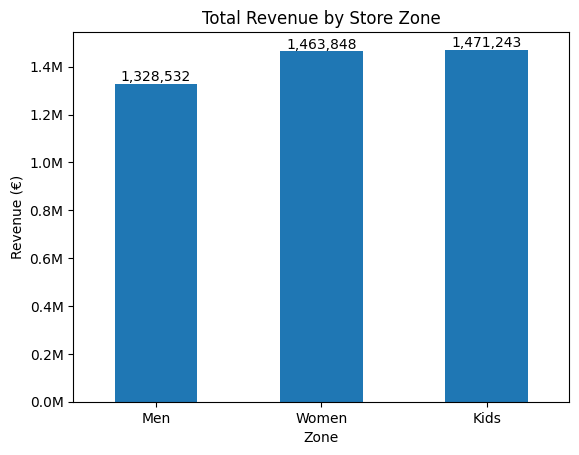

In [66]:
zone_sales.plot(kind="bar")

def format_func(value, tick_number):
    return f'{value / 1_000_000:.1f}M'

plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(format_func))

plt.title("Total Revenue by Store Zone")
plt.xlabel("Zone")
plt.ylabel("Revenue (€)")
plt.xticks(rotation = 0) 

plt.bar_label(plt.gca().containers[0], fmt='{:,.0f}')

plt.show()

### Interpretation: Total Revenue by Store Zone

The chart shows that the **Kids zone generates the highest revenue**, followed by **Women**, while the **Men section generates slightly lower revenue** in this dataset.

In real retail stores, the **Women's section often generates the highest revenue** because it usually offers a wider variety of products and customers may purchase multiple items in a single visit.

The strong revenue in the Kids section may occur because parents often buy several items for children at the same time.

Since this dataset was simulated for this project, the results may not fully represent real retail sales patterns.

Retail managers could use this type of analysis to understand which store areas contribute most to overall sales and where to focus merchandising and marketing efforts.

## Revenue by Product Category

Next, we analyze which product categories generate the most revenue in the store.

In [36]:
category_sales = df.groupby("category")["revenue"].sum().sort_values()

category_sales

category
Sportswear      297704.31
Bottoms         313485.22
Dresses         387137.11
Tops            417339.98
Outerwear       468753.95
Accessories     534548.51
Perfume         708889.28
Footwear       1135765.47
Name: revenue, dtype: float64

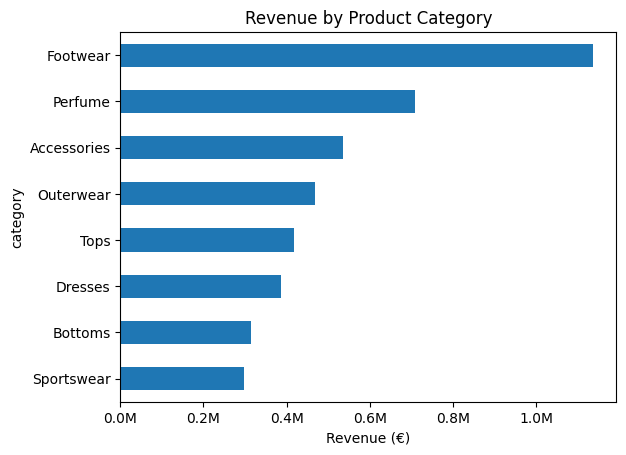

In [38]:
import matplotlib.ticker as ticker

category_sales.plot(kind="barh")

plt.title("Revenue by Product Category")
plt.xlabel("Revenue (€)")

def format_func(value, tick_number):
    return f'{value / 1_000_000:.1f}M'

plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(format_func))

### Interpretation: Revenue by Product Category

The chart shows the total revenue generated by each product category.

Footwear generates the highest revenue among all categories. Perfume and Accessories also contribute a large share of sales. These categories may benefit from higher prices or stronger customer demand.

Categories such as Bottoms and Sportswear generate lower revenue compared to other product groups.

This analysis helps identify which product categories drive the most value for the store, retail managers could focus on maintaining strong inventory and merchandising for high-performing categories while exploring ways to improve sales in lower-performing ones.

## Impact of Promotions

Retail stores often use promotions to encourage customers to buy more products.

Here we compare the average number of units sold when a promotion is active versus when it is not.

In [40]:
promo_sales = df.groupby("promotion")["units_sold"].mean().round(2)

promo_sales

promotion
No     16.79
Yes    16.26
Name: units_sold, dtype: float64

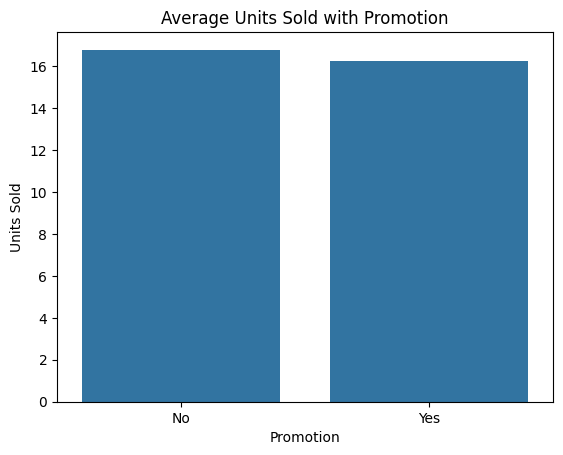

In [71]:
sns.barplot(x="promotion", y="units_sold", data=df, errorbar=None)

plt.title("Average Units Sold with Promotion")
plt.xlabel("Promotion")
plt.ylabel("Units Sold")

plt.show()

### Interpretation: Impact of Promotions

The chart compares the average number of units sold when promotions are applied versus when they are not.

In this dataset, the average units sold without promotions (16.79) is slightly higher than with promotions (16.26). This suggests that promotions do not significantly increase sales volume in this simulated dataset.

One possible explanation is that promotions may be applied to products with lower demand. In retail practice, discounts are often used to help sell slower-moving items rather than already popular products.

Since this dataset is simulated, the results may not fully represent real retail sales behaviour.

From a business perspective, this result suggests that promotions could be used more strategically. Retailers may benefit from focusing promotional efforts on lower-performing products to help improve their sales rather than mainly promoting products that already sell well.

## Promotion Analysis

### Promotion Distribution by Category

This chart shows how frequently promotions are applied across different product categories. It helps identify which products are more commonly included in promotional campaigns.

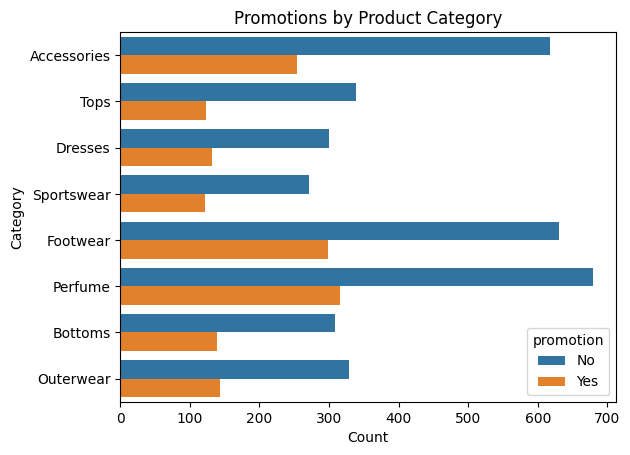

In [56]:
sns.countplot(y="category", hue="promotion", data=df)

plt.title("Promotions by Product Category")
plt.xlabel("Count")
plt.ylabel("Category")

plt.show()

### Impact of Promotions on Units Sold

Next, we examine whether promotions increase the number of units sold. 
We compare the average units sold when promotions are active versus when they are not.

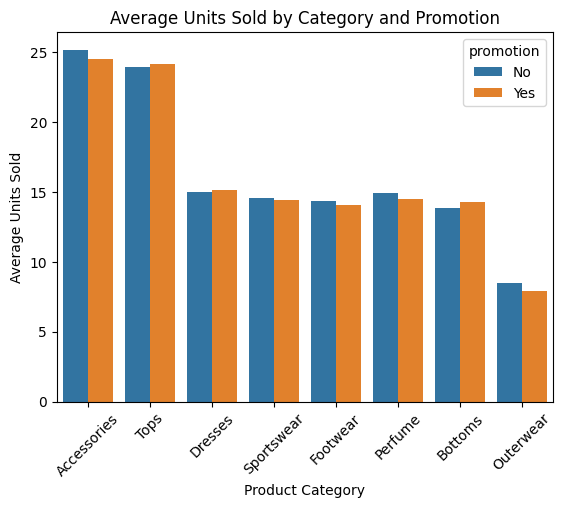

In [61]:
sns.barplot(x="category", y="units_sold", hue="promotion", data=df, errorbar=None)

plt.title("Average Units Sold by Category and Promotion")
plt.xlabel("Product Category")
plt.ylabel("Average Units Sold")

plt.xticks(rotation=45)

plt.show()

### Interpretation: Promotion Strategy

The first chart shows how often promotions are applied across different product categories. Categories such as Perfume, Footwear, and Accessories have the highest number of promotional transactions. However, in most categories, sales still occur more frequently without promotions.

The second chart compares the average number of units sold when promotions are active versus when they are not. The results show only small differences between promotional and non-promotional sales across most categories.

This suggests that promotions do not strongly increase the number of units sold per transaction in this dataset. Promotions may instead be used to attract customer attention, support marketing campaigns, or help move specific inventory items.

Retail managers may benefit from evaluating whether promotions are targeted toward the right products and whether promotional strategies could be adjusted to better improve sales performance.

## Key Insights

- **Revenue by store zone:** The Kids and Women zones generate slightly higher total revenue than the Men zone, suggesting that these sections contribute strongly to overall store performance.

- **Top revenue categories:** Footwear and Perfume generate the highest revenue among product categories. This may be influenced by higher product prices or strong customer demand.

- **Promotion usage:** Promotions are applied across several product categories, with Perfume, Footwear, and Accessories receiving the highest promotional activity.

- **Promotion effectiveness:** The analysis shows only small differences in average units sold between promotional and non-promotional sales. This suggests that promotions do not significantly increase the number of units sold per transaction in this dataset.

## Business Recommendations

Based on the analysis, several opportunities could be explored to improve sales performance:

- **Focus on high-revenue categories:** Products such as Footwear and Perfume generate the largest share of revenue. Maintaining strong inventory levels and product visibility in these categories may help sustain sales growth.

- **Evaluate promotional strategy:** Since promotions do not show a strong impact on units sold, retailers may benefit from reviewing how and where promotions are applied.

- **Support lower-performing categories:** Promotions could be used more strategically on lower-performing product groups such as Sportswear or Bottoms to help increase customer interest and improve sales performance.

- **Use data-driven promotion planning:** Monitoring sales patterns across categories can help managers decide which products should receive promotional support and when promotions are most effective.

This project demonstrates how data analysis can help retailers understand sales performance, evaluate promotional strategies, and support more informed business decisions.